In [1]:
import warnings
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
import os
import glob
import numpy as np

from nilearn import datasets, surface
from nilearn import plotting
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
import nibabel as nib

from brainiak import image, io
from brainiak.isc import isc, isfc, permutation_isc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white", context="notebook", font_scale=1, rc={"lines.linewidth": 2})

In [2]:
bids_dir = "/home/NEU480/datasets/narratives/"
fmriprep_dir = bids_dir + "derivatives/fmriprep/"
cleaned_dir = bids_dir + "derivatives/afni-nosmooth/"
stimuli_dir = bids_dir + "stimuli/"
transcript_dir =  "/home/vm5631/stimuli/transcripts_with_events/"
dir_nilearn = "/home/NEU480/datasets/nilearn_data"
code_dir = bids_dir + "code/"

In [66]:
import json
import pandas as pd


def json_to_events(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    events_list = []
    for event in data['annotations']['events']:
        events_list.append({
            'onset': event['start'],
            'duration': event['end'] - event['start'],
            'trial_type': event['label']  # e.g., 'punchline' or 'audience_laughter'
        })
    
    return pd.DataFrame(events_list)

# Example usage
events_live = json_to_events('stimuli/transcripts_with_events/pieman_audio.json')

In [4]:
events_live

,onset,duration,trial_type
0,69.218,2.582,punchline
1,71.954,1.546,audience_laughter
2,79.249,0.740,punchline
3,80.244,1.407,audience_laughter
4,86.093,2.561,punchline
5,88.592,2.128,audience_laughter
6,95.318,0.680,punchline
7,96.185,1.531,audience_laughter
8,115.150,1.421,punchline
9,131.451,0.861,punchline


In [67]:
events_pni = json_to_events('stimuli/transcripts_with_events/piemanpni_audio.json')

In [6]:
events_pni

,onset,duration,trial_type
0,66.491,3.963,punchline
1,76.179,1.421,punchline
2,81.243,2.722,punchline
3,88.343,1.241,punchline
4,104.676,1.921,punchline
5,121.258,1.000,punchline
6,123.198,1.721,punchline
7,129.760,2.961,punchline
8,142.424,2.481,punchline
9,151.979,2.782,punchline


In [7]:
tr = 1.5
n_scans_live = 300
n_scans_pni = 267
trim_front_live = 10
trim_back_live = 8
trim_front_pni = 6
trim_back_pni = 4
exclude_subjects_live = [1, 13, 14, 21, 22, 38, 56, 68, 69]
subs_live = [(i + 1) for i in range(16, 82)]
exclude_subjects_pni = [266, 268, 269, 270, 271, 280]
subs_pni = [(i + 1) for i in range(264, 315)]
frame_times = np.arange(n_scans_live) * tr

In [8]:
def remove_subjects(sub_list, exclude_list):
    cleaned_list = sub_list
    for sub in exclude_list:
        if sub in sub_list:
            cleaned_list.remove(sub) 
    return cleaned_list

In [9]:
subs_live = remove_subjects(subs_live, exclude_subjects_live)

In [10]:
subs_pni = remove_subjects(subs_pni, exclude_subjects_pni)
subs_pni.append(127)

In [11]:
len(subs_pni)

46

In [64]:
sub = "sub-025"
task = "pieman"
space = "MNI152NLin2009cAsym"

# Preprocessed fMRI data from Narratives
file_name = f"{sub}_task-{task}_space-{space}_res-native_desc-clean_bold.nii.gz"
file_dir = cleaned_dir + sub + "/func/"
func_fn = file_dir + file_name

print(func_fn)

/home/NEU480/datasets/narratives/derivatives/afni-nosmooth/sub-025/func/sub-025_task-pieman_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz


In [65]:
whole_brain_img = nib.load(func_fn)
data = whole_brain_img.get_fdata()
data.shape

(65, 77, 49, 300)

In [14]:
import random

def get_random_items(data_list, count):
    # random.sample raises an error if count > len(data_list)
    if count > len(data_list):
        return "Count is larger than the list size!"
    
    return random.sample(data_list, count)

In [15]:
live_random = get_random_items(subs_live, 5)
live_random

[32, 51, 37, 75, 33]

In [16]:
pni_random = get_random_items(subs_pni, 5)
pni_random

[288, 297, 315, 272, 282]

In [46]:
from nilearn.datasets import fetch_atlas_schaefer_2018

# Fetch Schaefer atlas with 400 parcels and 17 Yeo networks
n_parcels = 400
atlas = fetch_atlas_schaefer_2018(
    n_rois=n_parcels, yeo_networks=17, resolution_mm=2, data_dir=dir_nilearn
)

# Initialize labels masker with atlas parcels
masker = NiftiLabelsMasker(atlas.maps, labels=atlas.labels)

# Fit masker to extract mean time series for parcels
func_parcels = masker.fit_transform(func_fn)

print(func_parcels.shape)

[fetch_atlas_schaefer_2018] Dataset found in /home/NEU480/datasets/nilearn_data/schaefer_2018

(300, 400)


In [17]:
def parcellate(atlas, task, space, subs):
    parcellated = []
    for sub in subs:
        # Initialize labels masker with atlas parcels
        masker = NiftiLabelsMasker(atlas.maps, labels=atlas.labels)
        
        # Fit masker to extract mean time series for parcels
        file_name = f"sub-{sub:03d}_task-{task}_space-{space}_res-native_desc-clean_bold.nii.gz"
        file_dir = f"{cleaned_dir}sub-{sub:03d}/func/"
        func_fn = file_dir + file_name
        func_parcels = masker.fit_transform(func_fn)       
        parcellated.append(func_parcels)

    return parcellated

In [20]:
live_parcellated = parcellate(atlas, "pieman", space, live_random)

In [21]:
live_parcellated[0].shape

(300, 400)

In [22]:
# This is your personal scratch directory
net_id = os.environ['USER']  # make sure this is your netid
scratch_folder = f"/scratch/network/{net_id}/"

# Make a directory to store your preprocessed data.
roi_dir = scratch_folder + "thesis/roi_masks"

In [68]:
laughter_live = events_live[events_live['trial_type'] == 'audience_laughter']
long_laughter_live = laughter_live[laughter_live['duration'] > 2.0]

In [69]:
long_laughter_live = long_laughter_live[long_laughter_live['duration'] < 9]
long_laughter_live

,onset,duration,trial_type
5,88.592,2.128,audience_laughter
18,172.800,2.244,audience_laughter
24,226.040,3.001,audience_laughter
27,265.031,2.046,audience_laughter
33,300.412,2.970,audience_laughter
41,352.425,2.575,audience_laughter
47,389.081,3.568,audience_laughter
48,395.520,2.400,audience_laughter
52,421.107,3.464,audience_laughter


In [24]:
test_sub = "sub-025"
test_fn = f"{cleaned_dir}{test_sub}/func/" + f"{test_sub}_task-{task}_space-{space}_res-native_desc-clean_bold.nii.gz"

design_matrix = make_first_level_design_matrix(
    frame_times,
    laughter_live,
    drift_model=None, # Data is already filtered
    hrf_model='glover'
)

wb_glm = FirstLevelModel(
    t_r=1.5,
    # mask_img= roi_dir + 'vs.nii.gz', # Combined mask of all ROIs
    signal_scaling=False,
    noise_model='ar1',
    standardize=False
)

wb_glm.fit(nib.load(test_fn), design_matrices=design_matrix)

wb_z_map_laughter = wb_glm.compute_contrast('audience_laughter')

In [25]:
wb_z_map_laughter

In [49]:
len(frame_times)

300

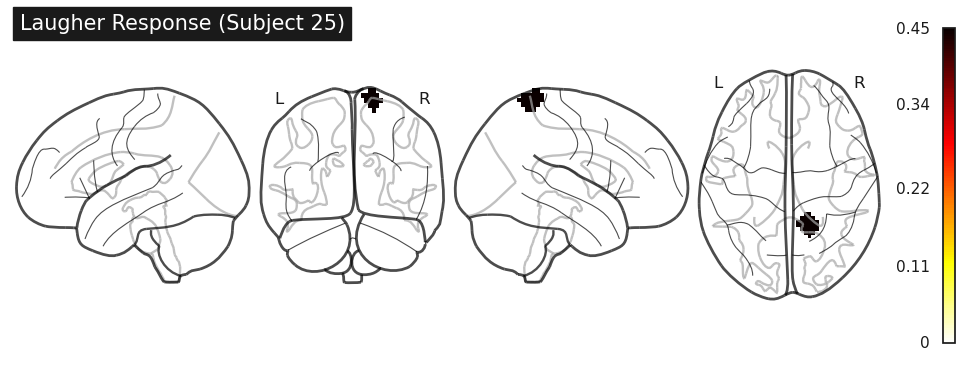

In [70]:
design_matrix = make_first_level_design_matrix(
    frame_times,
    long_laughter_live,
    drift_model=None, # Data is already filtered
    hrf_model='glover'
)

wb_glm = FirstLevelModel(
    t_r=1.5,
    signal_scaling=False,
    noise_model='ar1',
    standardize=False
)

wb_glm.fit(whole_brain_img, design_matrices=design_matrix)

wb_z_map_laughter = wb_glm.compute_contrast('audience_laughter')

plotting.plot_glass_brain(
    wb_z_map_laughter, 
    threshold=0,  # Corresponds roughly to p < 0.001
    colorbar=True, 
    display_mode='lyrz',  # Shows Left, Right, and Coronal views
    title='Laugher Response (Subject 25)'
)
plotting.show()


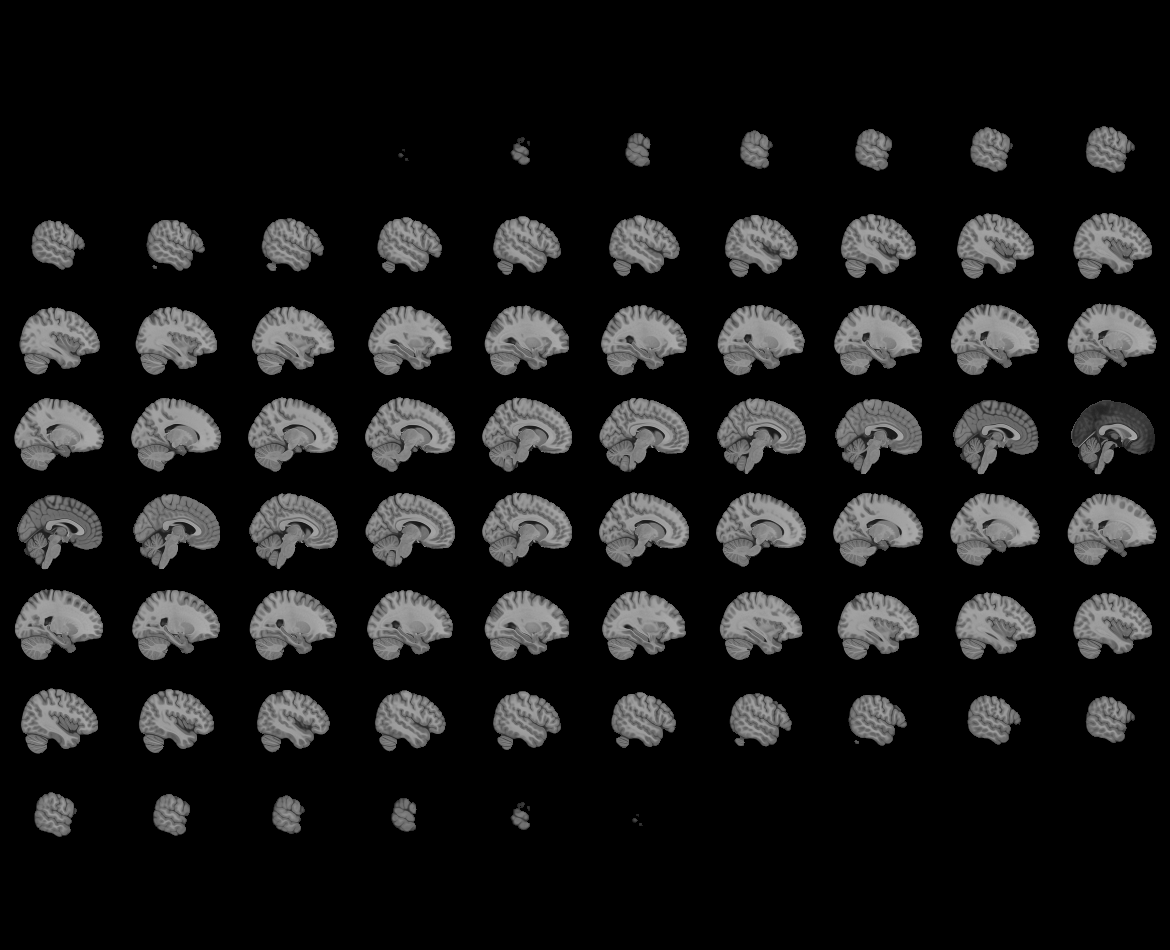
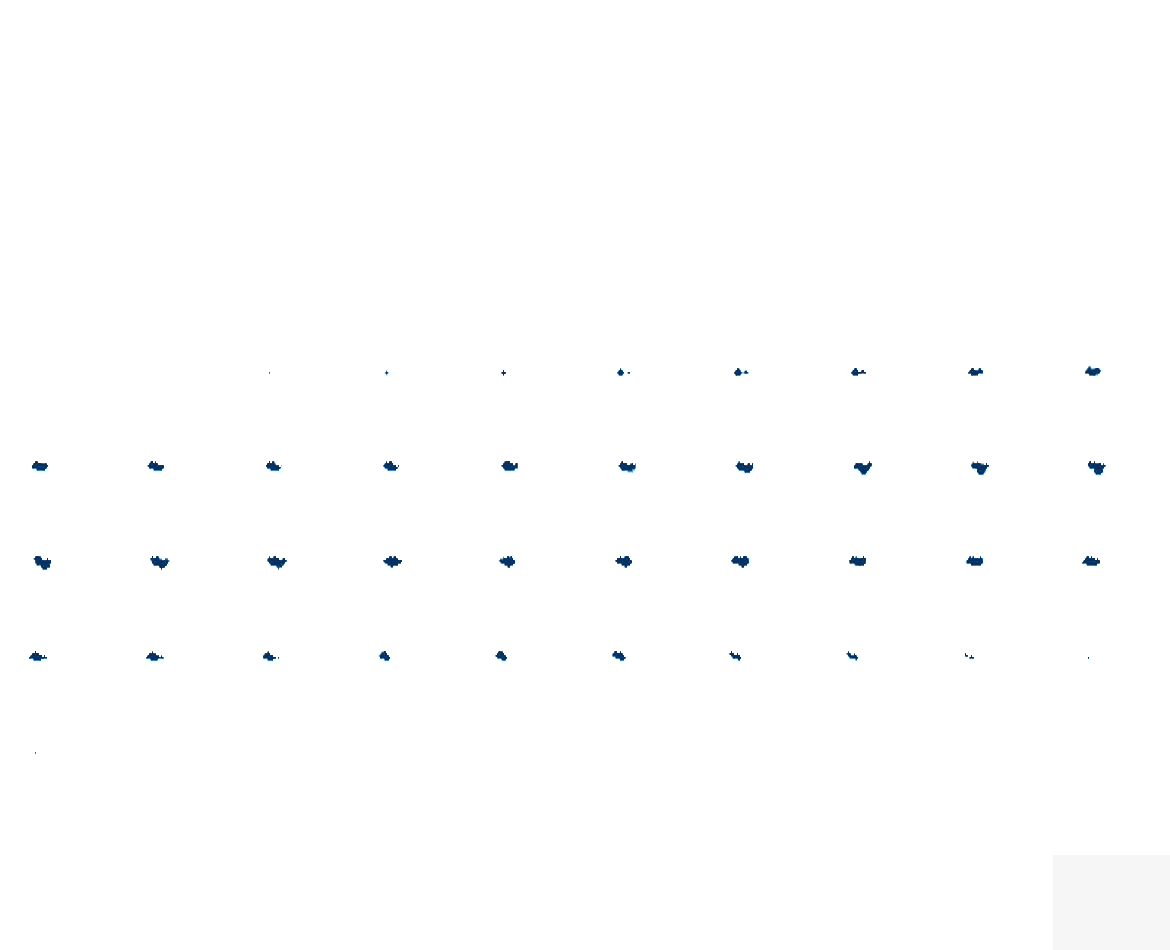

In [63]:
plotting.view_img(wb_z_map_laughter, threshold=0)

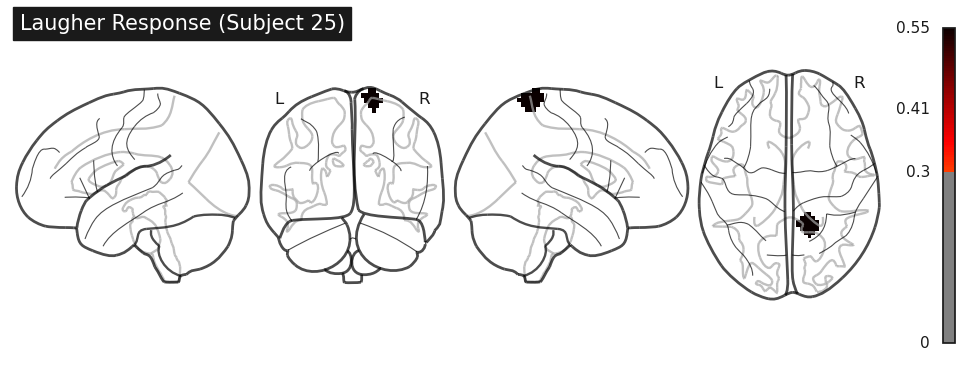

In [26]:
plotting.plot_glass_brain(
    wb_z_map_laughter, 
    threshold=0.3,  # Corresponds roughly to p < 0.001
    colorbar=True, 
    display_mode='lyrz',  # Shows Left, Right, and Coronal views
    title='Laugher Response (Subject 25)'
)
plotting.show()

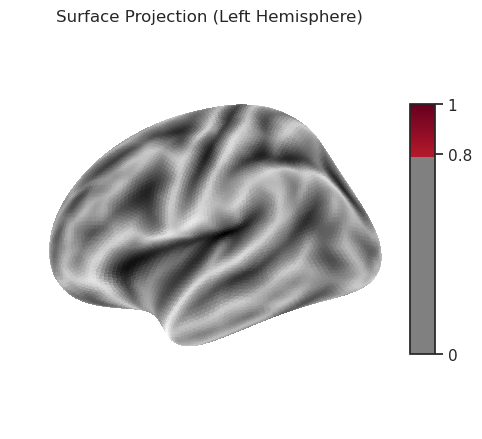

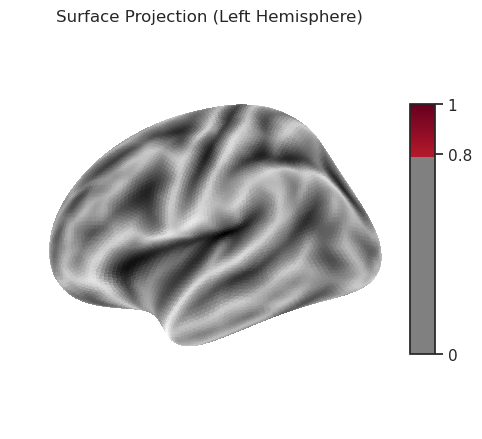

In [27]:
fsaverage = datasets.fetch_surf_fsaverage()

# Project the 3D volume to the surface
texture = surface.vol_to_surf(wb_z_map_laughter, fsaverage.pial_left)

# Plot it
plotting.plot_surf_stat_map(
    fsaverage.infl_left, 
    texture, 
    hemi='left', 
    title='Surface Projection (Left Hemisphere)',
    colorbar=True, 
    threshold=0.8, 
    bg_map=fsaverage.sulc_left
)


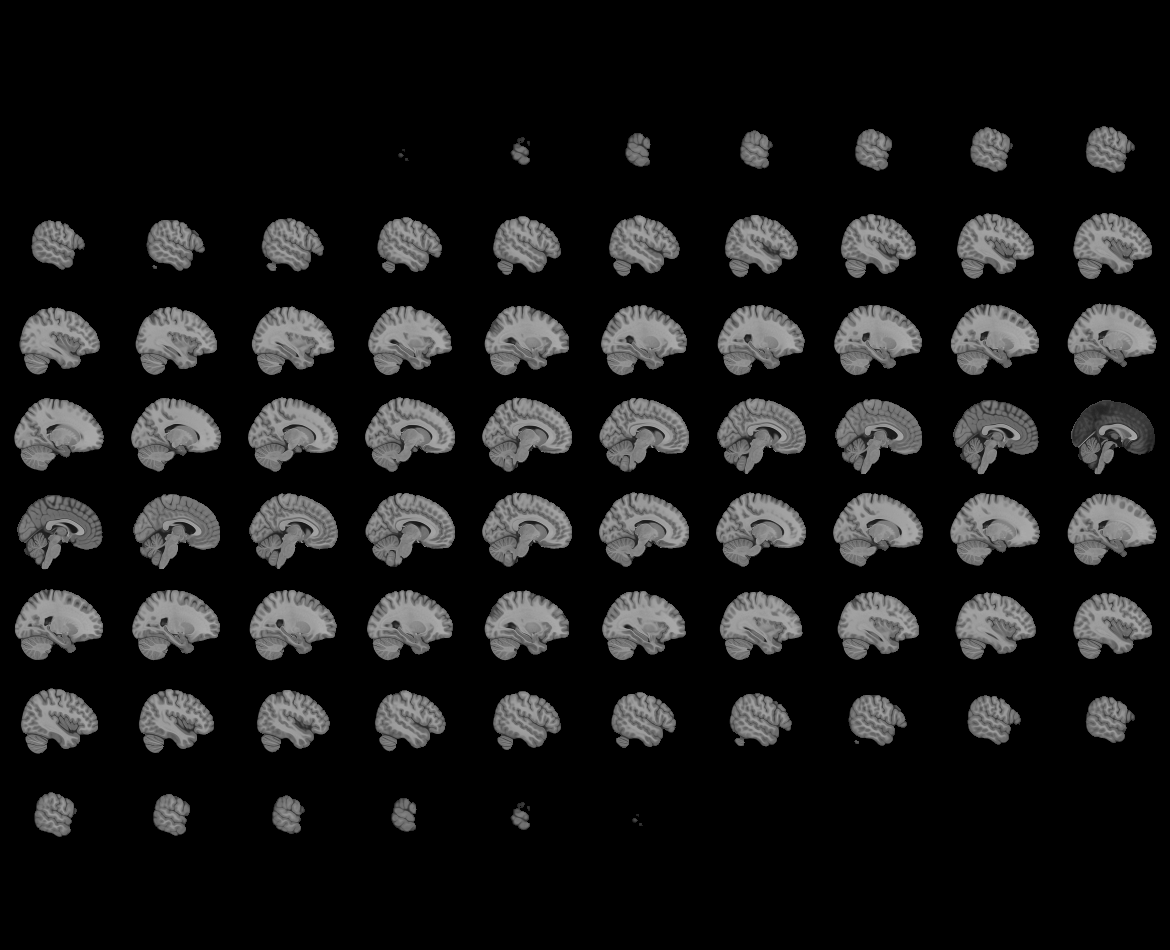
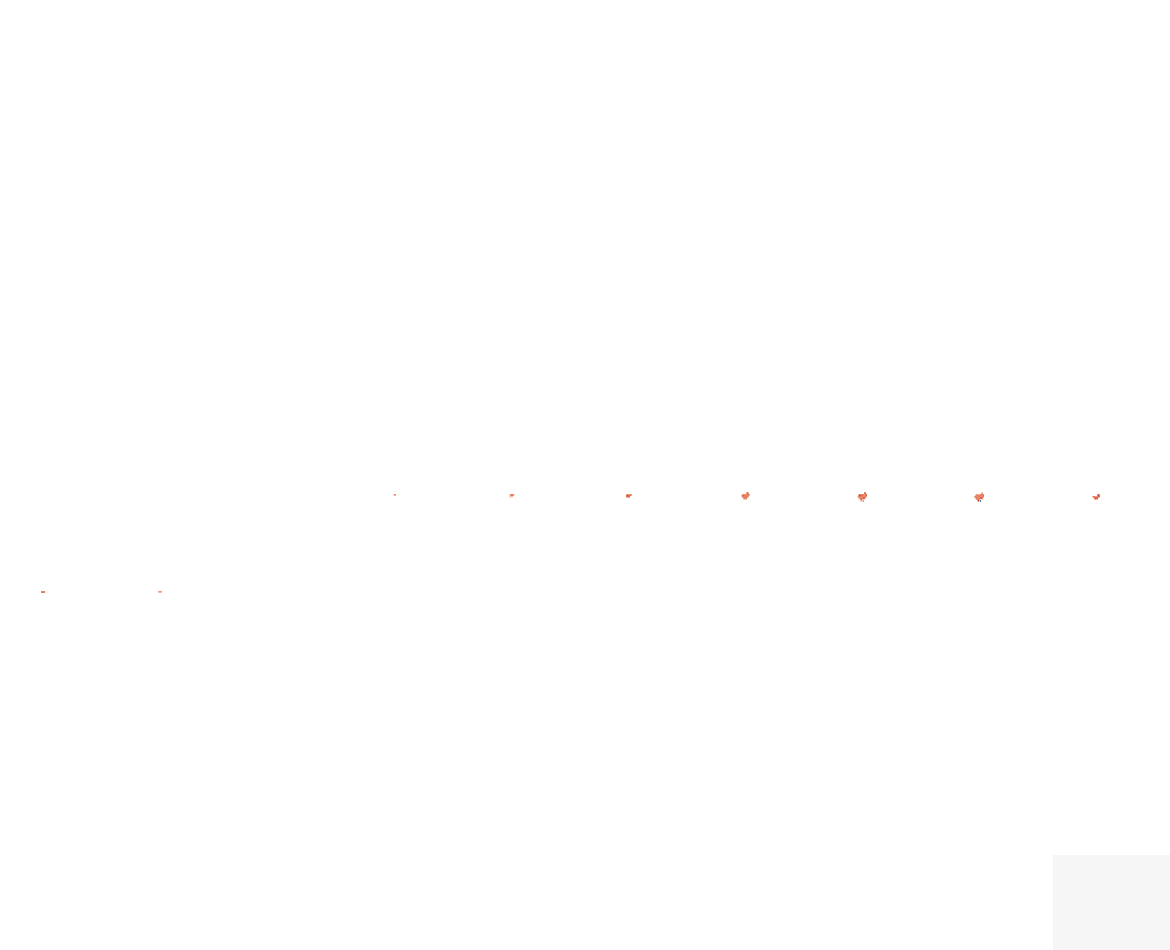

In [28]:
plotting.view_img(wb_z_map_laughter, threshold=0.4)

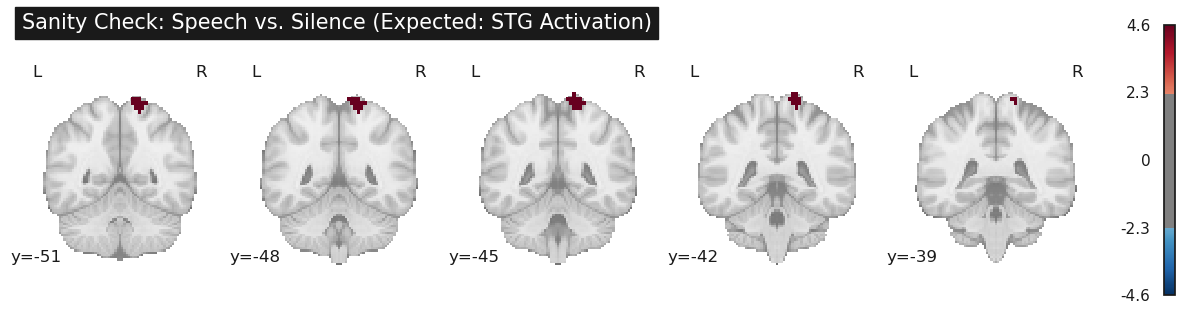

In [65]:
intro_offset = 15.0   # The 15-second intro music/silence in Pie Man
story_duration = 415.0 # The story itself is ~415s

# --- STEP 1: CREATE THE "SPEECH" EVENT ---
# We create one single block that covers the entire duration of the speech.
events_sanity = pd.DataFrame([{
    'onset': intro_offset, 
    'duration': story_duration, 
    'trial_type': 'speech'
}])

design_matrix = make_first_level_design_matrix(
    frame_times,
    events_sanity,
    drift_model=None,  # Crucial: Data is already high-pass filtered
    hrf_model='glover'
)

# --- STEP 3: FIT THE GLM ---
# Since you are using the AFNI 'clean' residuals:
# 1. signal_scaling=False (Data is already centered at zero)
# 2. standardize=False
fmri_glm = FirstLevelModel(
    t_r=tr,
    noise_model='ar1', 
    standardize=False, 
    signal_scaling=False
)

fmri_glm = fmri_glm.fit(nib.load(test_fn), design_matrices=design_matrix)

# --- STEP 4: COMPUTE THE CONTRAST ---
z_map_speech = fmri_glm.compute_contrast('speech', output_type='z_score')

# --- STEP 5: VISUALIZE ---
# We use a high threshold (3.1) because speech is a very strong stimulus.
plotting.plot_stat_map(
    z_map_speech, 
    threshold=2.3, 
    display_mode='y', 
    cut_coords=5, # Shows 5 axial slices
    title='Sanity Check: Speech vs. Silence (Expected: STG Activation)'
)
plotting.show()

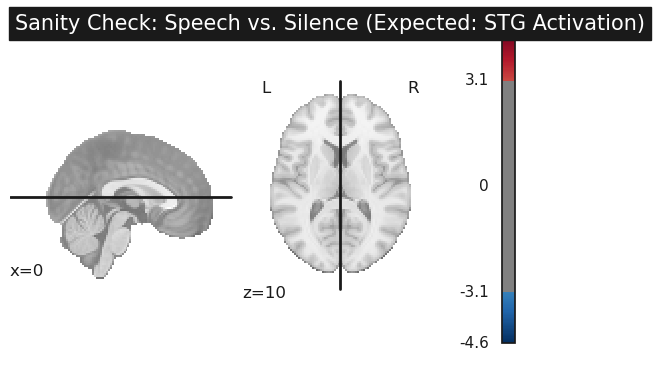

In [68]:
plotting.plot_stat_map(
    z_map_speech, 
    threshold=3.1, 
    display_mode='xz', 
    cut_coords=[0, 10], 
    title='Sanity Check: Speech vs. Silence (Expected: STG Activation)'
)
plotting.show()

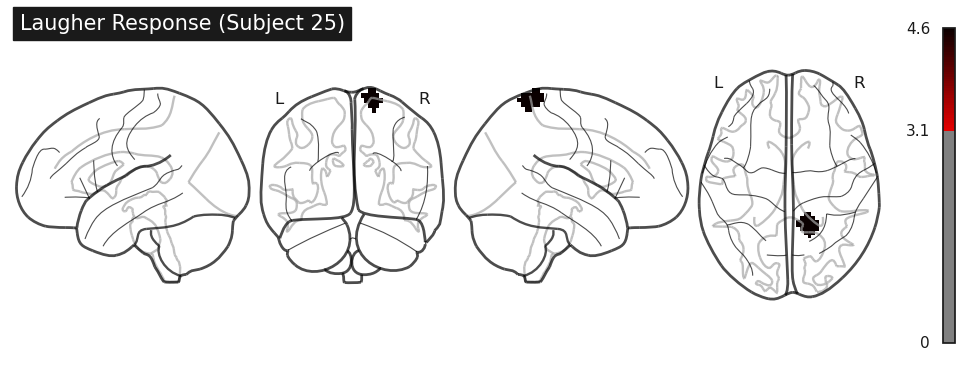

In [70]:
plotting.plot_glass_brain(
    z_map_speech, 
    threshold=3.1,  # Corresponds roughly to p < 0.001
    colorbar=True, 
    display_mode='lyrz',  # Shows Left, Right, and Coronal views
    title='Laugher Response (Subject 25)'
)
plotting.show()

In [69]:
test_img = nib.load(test_fn)
test_img.shape

(65, 77, 49, 300)


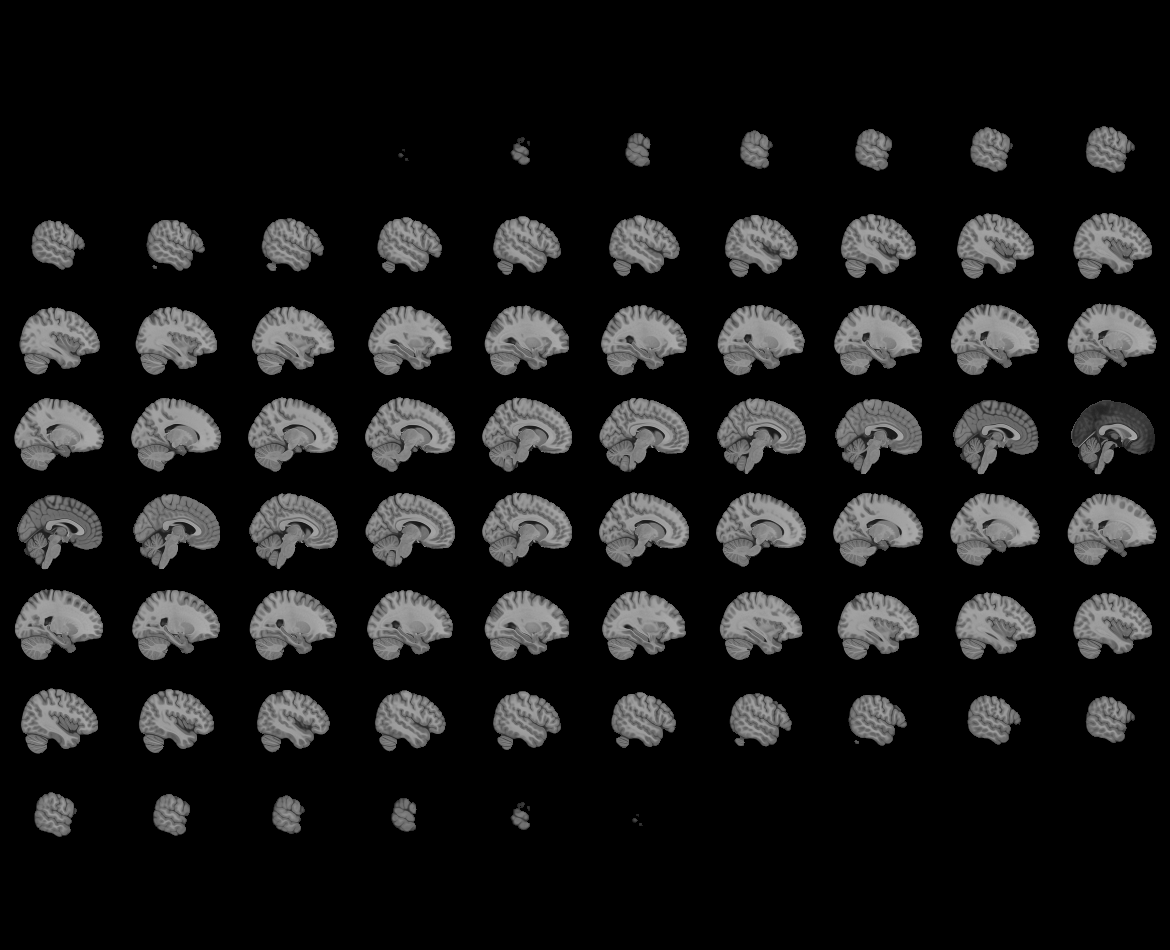
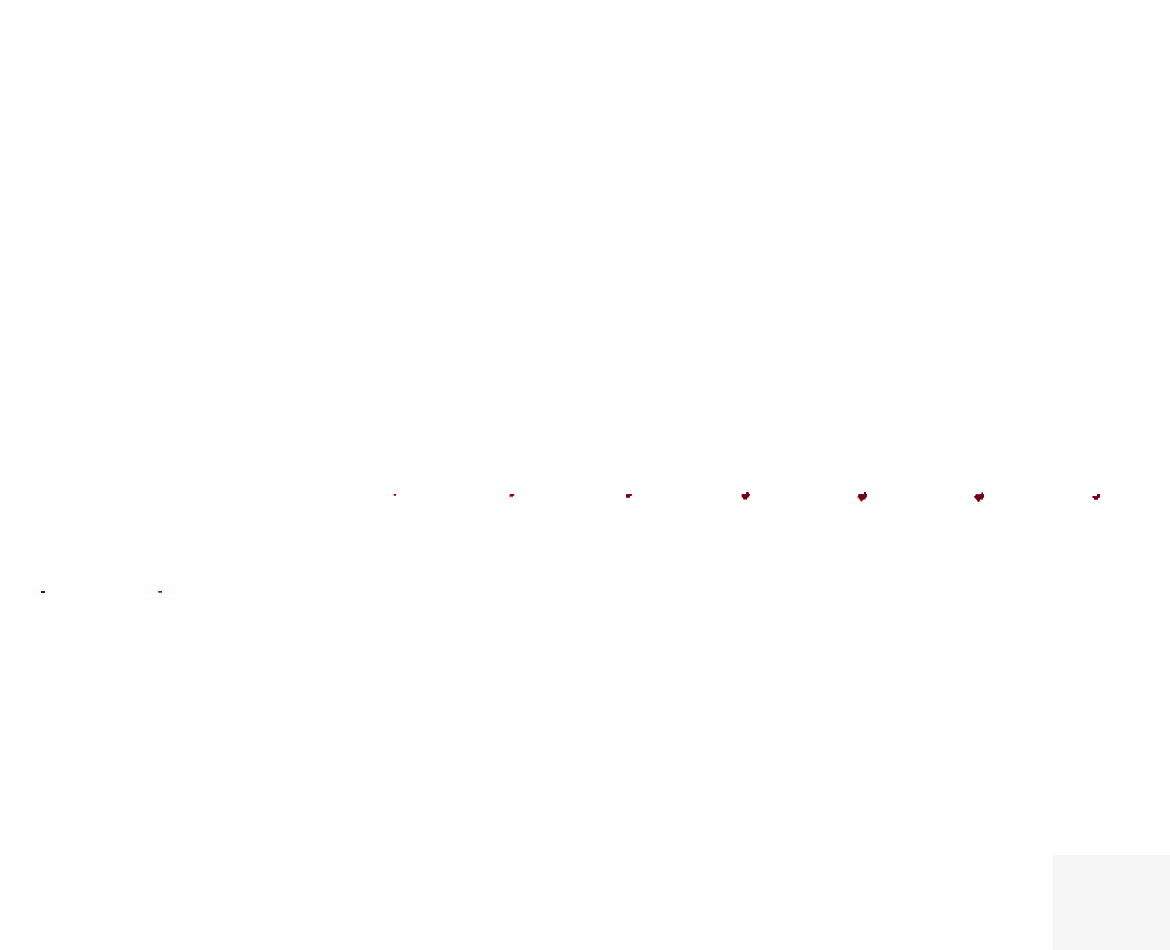

In [72]:
plotting.view_img(z_map_speech, threshold=0.8)

In [29]:
test_sub = "sub-025"
test_brain_mask = f"{fmriprep_dir}{test_sub}/func/" + f"{test_sub}_task-{task}_space-{space}_res-native_desc-brain_mask.nii.gz"
test_fn = f"{fmriprep_dir}{test_sub}/func/" + "sub-025_task-pieman_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii.gz"
test_img = nib.load(test_fn)

# test_masker = NiftiMasker(mask_img=test_brain_mask)
# test_img = test_masker.fit_transform(test_fn)

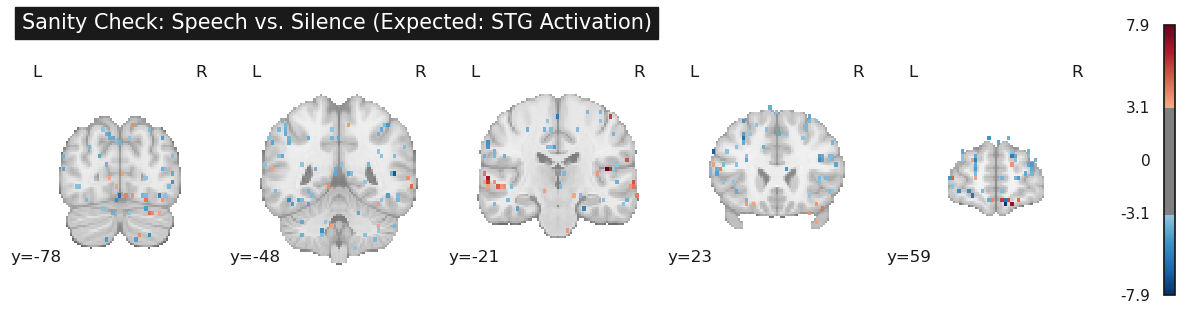

In [32]:
intro_offset = 15.0   # The 15-second intro music/silence in Pie Man
story_duration = 415.0 # The story itself is ~415s

# --- STEP 1: CREATE THE "SPEECH" EVENT ---
# We create one single block that covers the entire duration of the speech.
events_sanity = pd.DataFrame([{
    'onset': intro_offset, 
    'duration': story_duration, 
    'trial_type': 'speech'
}])

design_matrix = make_first_level_design_matrix(
    frame_times,
    events_sanity,
    drift_model=None,
    hrf_model='glover'
)

# --- STEP 3: FIT THE GLM ---
# Since you are using the AFNI 'clean' residuals:
# 1. signal_scaling=False (Data is already centered at zero)
# 2. standardize=False
fmri_glm = FirstLevelModel(
    t_r=tr,
    noise_model='ar1', 
    standardize=False, 
    signal_scaling=False
)

fmri_glm = fmri_glm.fit(test_img, design_matrices=design_matrix)

# --- STEP 4: COMPUTE THE CONTRAST ---
z_map_speech = fmri_glm.compute_contrast('speech', output_type='z_score')

# --- STEP 5: VISUALIZE ---
# We use a high threshold (3.1) because speech is a very strong stimulus.
plotting.plot_stat_map(
    z_map_speech, 
    threshold=3.1, 
    display_mode='y', 
    cut_coords=5, # Shows 5 axial slices
    title='Sanity Check: Speech vs. Silence (Expected: STG Activation)'
)
plotting.show()


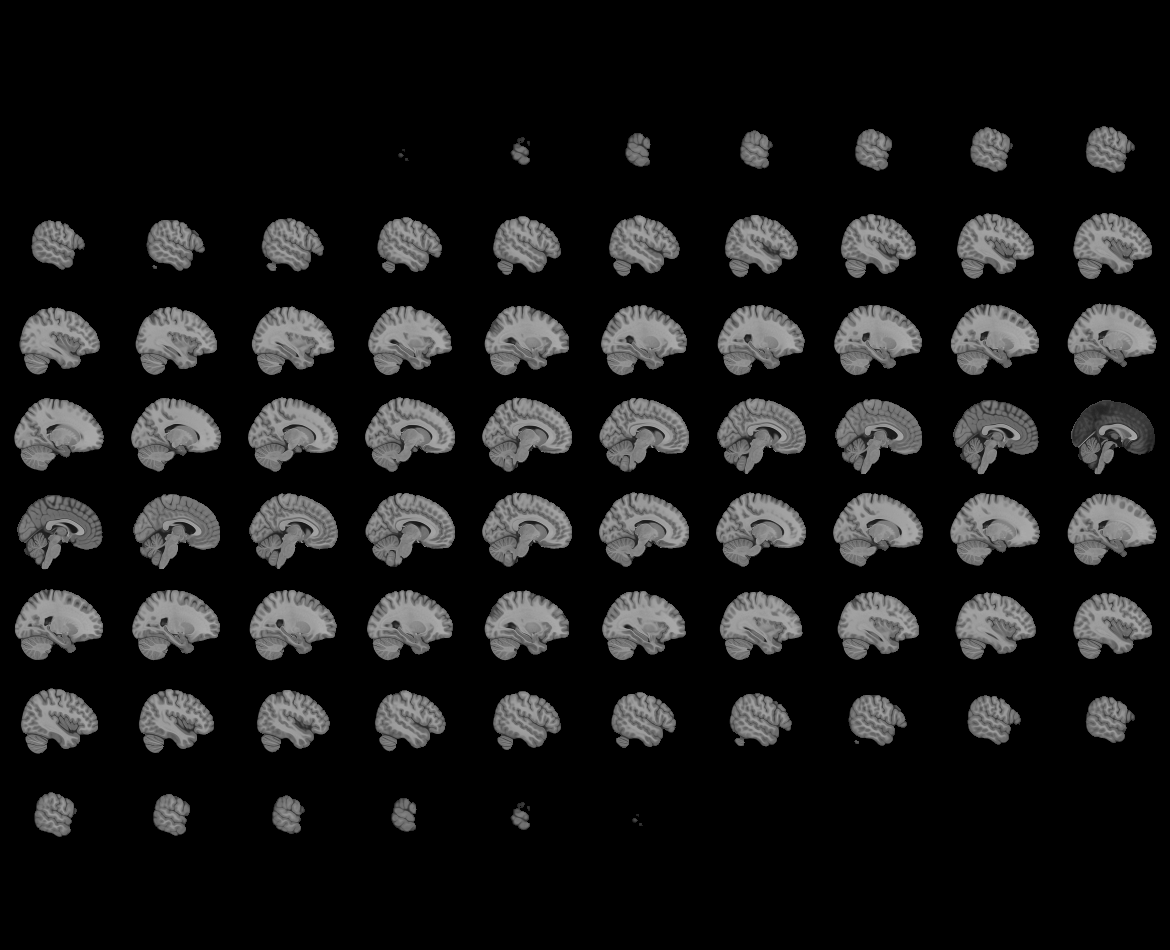
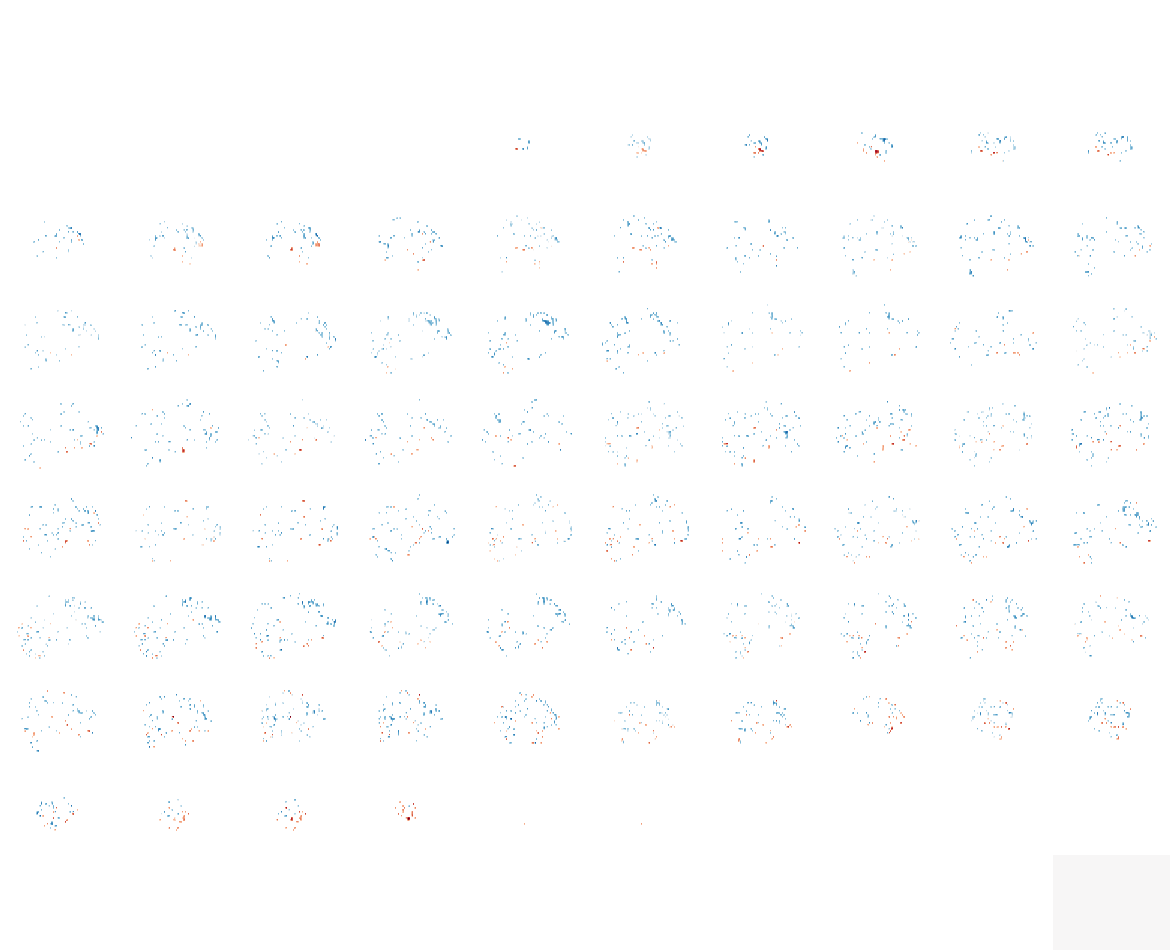

In [33]:
plotting.view_img(z_map_speech, threshold=3.1)

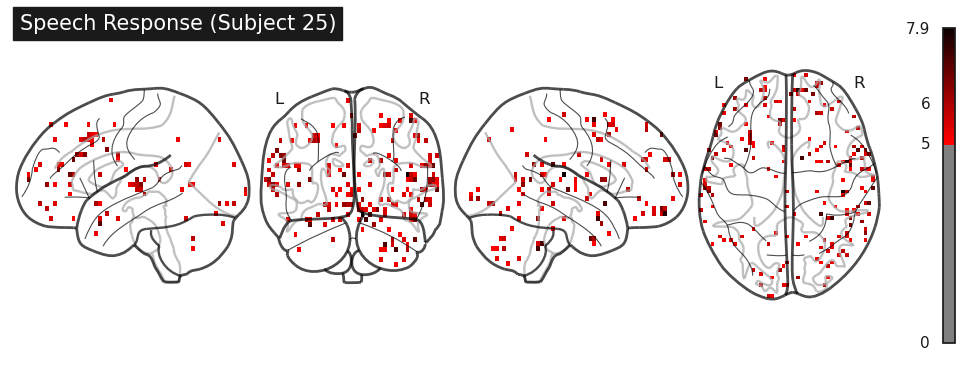

In [35]:
plotting.plot_glass_brain(
    z_map_speech, 
    threshold=5,  # Corresponds roughly to p < 0.001
    colorbar=True, 
    display_mode='lyrz',  # Shows Left, Right, and Coronal views
    title='Speech Response (Subject 25)'
)
plotting.show()

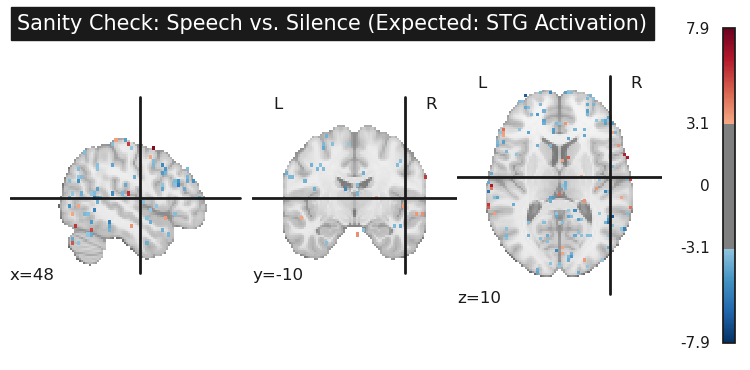

In [37]:
plotting.plot_stat_map(
    z_map_speech, 
    threshold=3.1, 
    display_mode='ortho', 
    cut_coords=(48, -10, 10),
    title='Sanity Check: Speech vs. Silence (Expected: STG Activation)'
)
plotting.show()

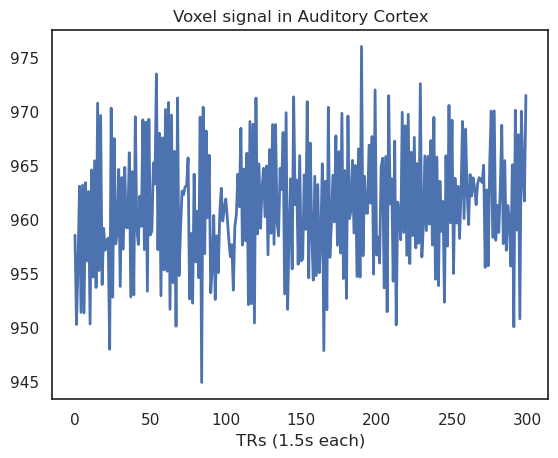

In [38]:
from nilearn.maskers import NiftiSpheresMasker
# A coordinate in the Right Auditory Cortex
coords = [(48, -10, 10)] 
masker = NiftiSpheresMasker(coords, radius=5)
# Use your NON-cleaned data here
real_signal = masker.fit_transform(test_img)

plt.plot(real_signal)
plt.title("Voxel signal in Auditory Cortex")
plt.xlabel("TRs (1.5s each)")
plt.show()


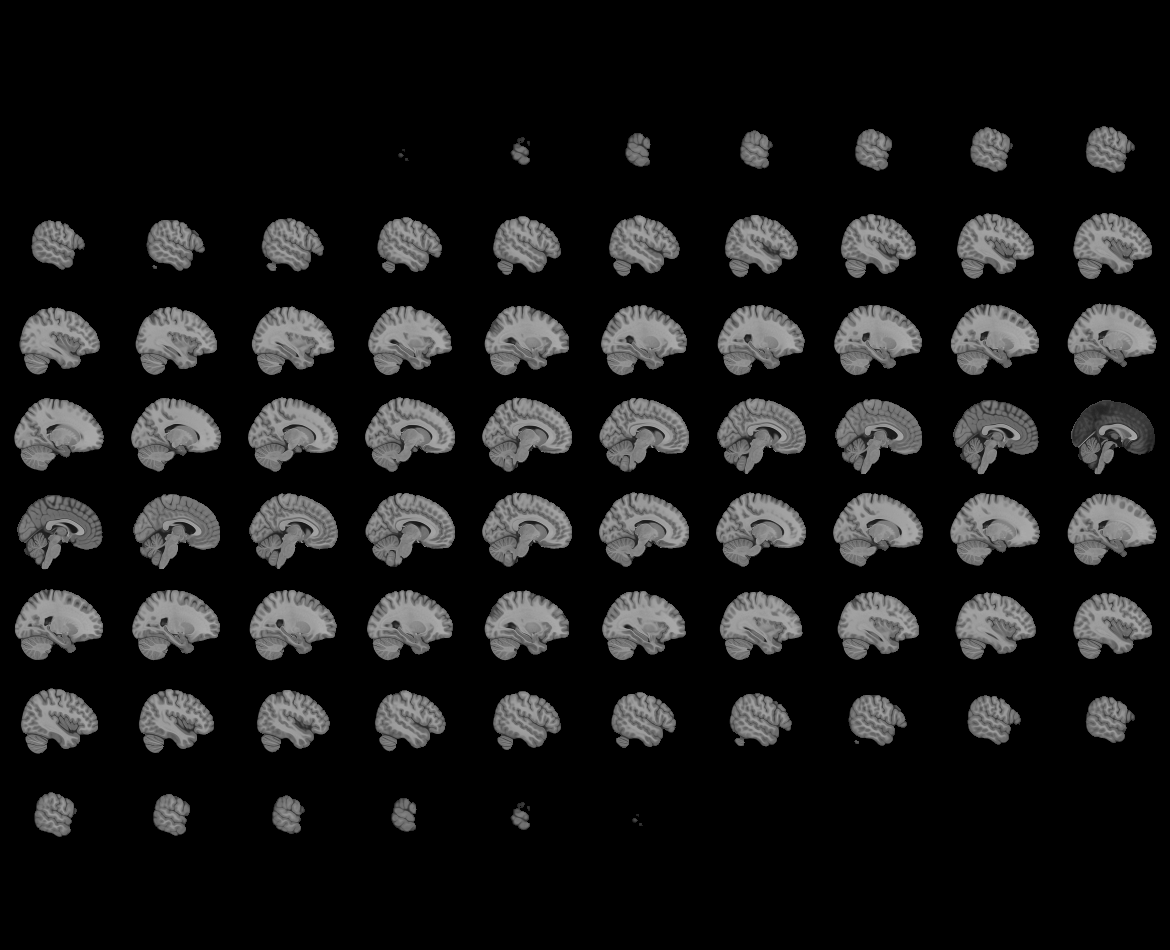
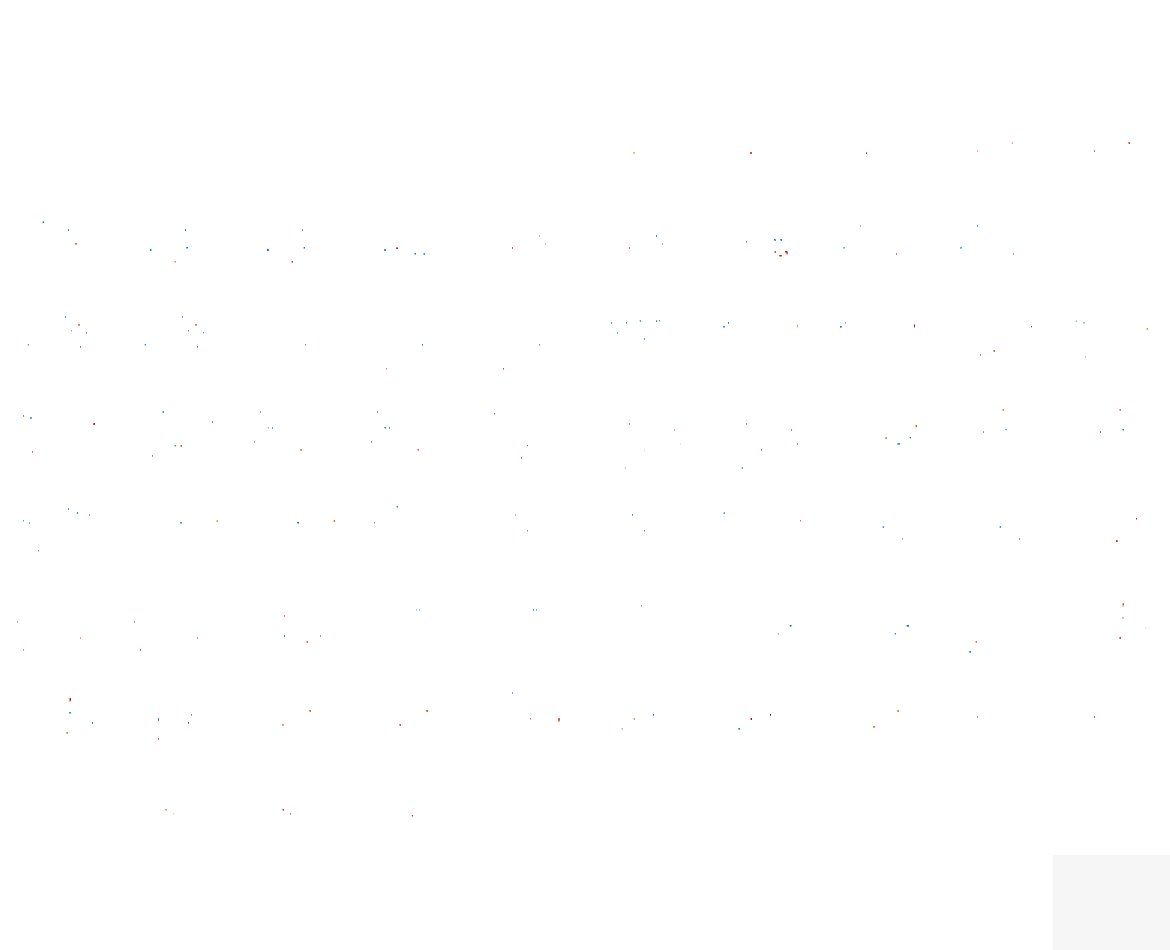

In [43]:
design_matrix = make_first_level_design_matrix(
    frame_times,
    laughter_live,
    drift_model=None,
    hrf_model='glover'
)

# --- STEP 3: FIT THE GLM ---
# Since you are using the AFNI 'clean' residuals:
# 1. signal_scaling=False (Data is already centered at zero)
# 2. standardize=False
fmri_glm = FirstLevelModel(
    t_r=tr,
    # noise_model=None, 
    standardize=False, 
    signal_scaling=False
)

fmri_glm = fmri_glm.fit(test_img, design_matrices=design_matrix)

# --- STEP 4: COMPUTE THE CONTRAST ---
z_map_laughter = fmri_glm.compute_contrast('audience_laughter', output_type='z_score')

# --- STEP 5: VISUALIZE ---
# We use a high threshold (3.1) because speech is a very strong stimulus.
plotting.view_img(z_map_laughter, threshold=3.1)

In [79]:
sub = "sub-310"
task = "piemanpni"
space = "MNI152NLin2009cAsym"

# Preprocessed fMRI data from Narratives
file_name = f"{sub}_task-{task}_space-{space}_res-native_desc-clean_bold.nii.gz"
file_dir = cleaned_dir + sub + "/func/"
func_fn = file_dir + file_name

print(func_fn)

/home/NEU480/datasets/narratives/derivatives/afni-nosmooth/sub-310/func/sub-310_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz


In [76]:
!ls -l {func_fn}

lrwxrwxrwx 1 zzada neu480 144 Feb 17 07:47 /home/NEU480/datasets/narratives/derivatives/afni-nosmooth/sub-282/func/sub-282_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz -> ../../.git/annex/objects/92/W9/MD5E-s135161853--f84c1d64f57780f9d8c2b38e74efa309.nii.gz/MD5E-s135161853--f84c1d64f57780f9d8c2b38e74efa309.nii.gz


In [80]:
pni_test = nib.load(func_fn)

In [81]:
pni_test.shape

(78, 93, 78, 294)